Ce TP est dédié aux techniques de restauration d'images dégradées. L'objectif est d'implémenter des filtres de débruitage et d'utiliser des métriques mathématiques pour valider l'efficacité de la restauration.

**Contenu du Notebook :**
* **Restauration Spatiale :** Application de filtres de lissage pour atténuer le bruit.
* **Évaluation par PSNR :** Implémentation du calcul du Peak Signal-to-Noise Ratio pour mesurer la fidélité de l'image récupérée.
* **Optimisation de Paramètres :** Développement d'une fonction de recherche automatique du meilleur noyau de filtrage (Best Sbox) basé sur la maximisation du PSNR.

# 1 - Lecture des images :

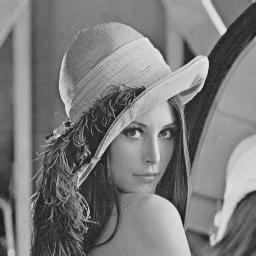

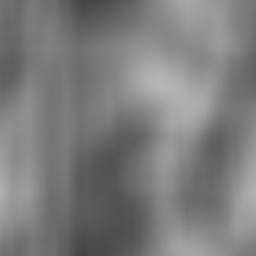

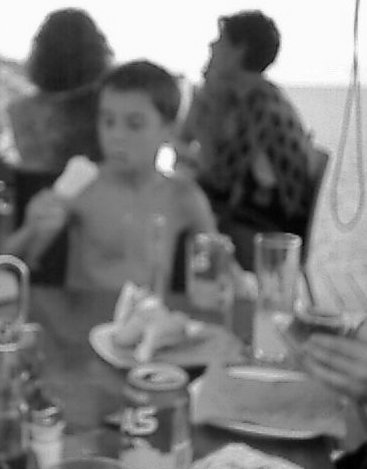

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

# Charger l'image Lena
lena_image = cv2.imread('/content/lena.jpg')

# Charger l'image noisy
noisy_image = cv2.imread('/content/noisy.jpg')

# Charger l'image test_blur
test_blur_image = cv2.imread('/content/test_blur.jpg')

# Afficher les images (facultatif)
cv2_imshow( lena_image)
cv2_imshow(noisy_image)
cv2_imshow(test_blur_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

# 2 - Convolution avec un filtre PB de taille 5x5:

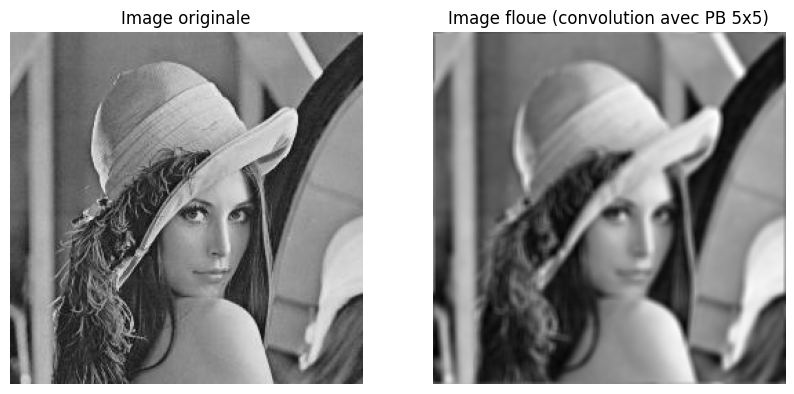

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt



# Convertir l'image en niveaux de gris
lena_image = cv2.cvtColor(lena_image, cv2.COLOR_BGR2GRAY)

# Définir un filtre passe-bas 5x5 (par exemple, une moyenne)
kernel = np.ones((5, 5), dtype=np.float32) / 25  # Créer un filtre moyenne

# Convoluer l'image Léna avec le filtre passe-bas
lena_blurred = convolve2d(lena_image, kernel, mode='same', boundary='wrap')

# Afficher l'image originale et l'image floue avec Matplotlib
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(lena_image, cmap='gray')
plt.title('Image originale')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(lena_blurred, cmap='gray')
plt.title('Image floue (convolution avec PB 5x5)')
plt.axis('off')

plt.show()


# L'image restaurée avec un filtre de Wiener:

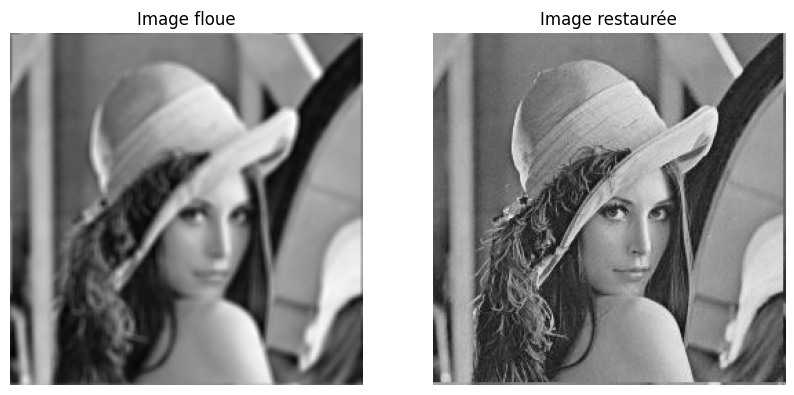

In [ ]:
import os
import numpy as np
from numpy.fft import fft2, ifft2
from scipy.signal import gaussian, convolve2d
import matplotlib.pyplot as plt

def wiener_filter(img, kernel, K):
	kernel /= np.sum(kernel)
	dummy = np.copy(img)
	dummy = fft2(dummy)
	kernel = fft2(kernel, s = img.shape)
	kernel = np.conj(kernel) / (np.abs(kernel) ** 2 + K)
	dummy = dummy * kernel
	dummy = np.abs(ifft2(dummy))
	return dummy

lena_restored = wiener_filter(lena_blurred, kernel, 0.00001)

# Afficher l'image originale et l'image floue avec Matplotlib
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(lena_blurred, cmap='gray')
plt.title('Image floue')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(lena_restored, cmap='gray')
plt.title('Image restaurée')
plt.axis('off')

plt.show()

Après l'application du filtre de Wiener, on remarque une nette amélioration de la clarté de l'image par rapport à l'image floutée avec le filtre PB.  le filtre de Wiener parvient à restaurer les détails importants en minimisant l'erreur quadratique moyenne. C'est le filtre le plus efficace ici car il s'adapte au niveau de bruit présent dans le signal.

# 3 - Image de Léna avec flou et déplacement:



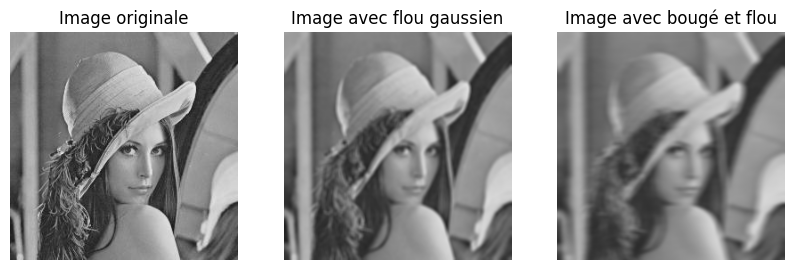

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Appliquer un flou gaussien à l'image
lena_blurred = cv2.GaussianBlur(lena_image, (5, 5), sigmaX=2, sigmaY=2)

# Définir le noyau de flou de mouvement
kernel_size = 10
kernel_bm = np.zeros((kernel_size, kernel_size))
kernel_bm[int((kernel_size-1)/2), :] = np.ones(kernel_size)
kernel_bm /= kernel_size

# Appliquer le flou de mouvement à l'image
lena_moved_blurred = cv2.filter2D(lena_blurred, -1, kernel_bm)
cv2.imwrite('lena_moved_blurred.png', lena_moved_blurred)
# Afficher les images
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(lena_image, cv2.COLOR_BGR2RGB))
plt.title('Image originale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(lena_blurred, cv2.COLOR_BGR2RGB))
plt.title('Image avec flou gaussien')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(lena_moved_blurred, cv2.COLOR_BGR2RGB))
plt.title('Image avec bougé et flou')
plt.axis('off')

plt.show()


# Restauration de l'image avec un filtre de Wiener:

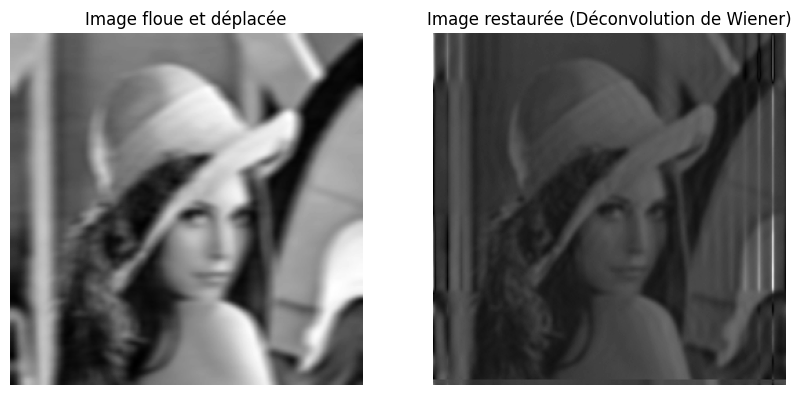

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import color, restoration


# Convertir l'image en niveaux de gris
lena_restored = wiener_filter(lena_moved_blurred, kernel_bm, 0.01)

# Afficher les images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(lena_moved_blurred, cmap='gray')
plt.title('Image floue et déplacée')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(lena_restored, cmap='gray')
plt.title('Image restaurée (Déconvolution de Wiener)')
plt.axis('off')

plt.show()


On remarque qu'après le déplacement, l'image restaurée par Wiener est moins nette et globalement plus sombre. Cela s'explique par la nature statistique du filtre : pour éviter d'amplifier le bruit généré par le flou de mouvement, le filtre atténue certaines fréquences du signal. Le 'noircissement' montre que le filtre a dû sacrifier une partie de l'intensité pour stabiliser l'image.

# 4 - Application du filtre de Lucy-Richardson sur l'image test_blur:

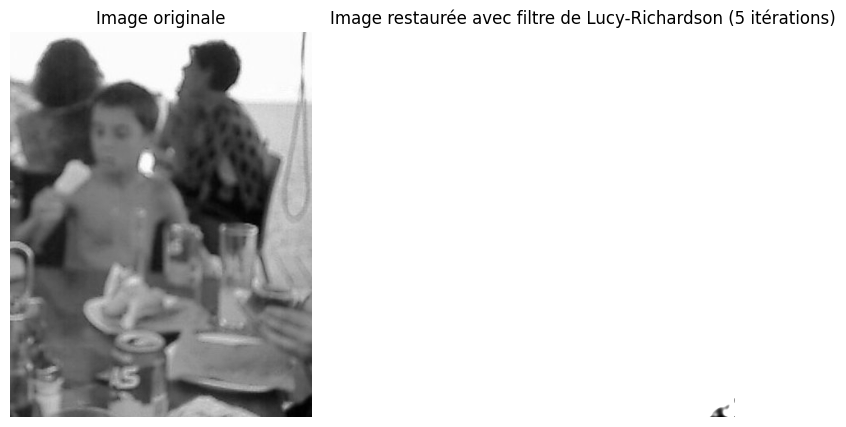

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import restoration

# Charger l'image test_blur
test_blur_image = cv2.imread('/content/test_blur.jpg')

# Convertir l'image en niveaux de gris
test_blur_gray = cv2.cvtColor(test_blur_image, cv2.COLOR_BGR2GRAY)
def gaussian_kernel(size, sigma):
    kernel = np.zeros((size, size))
    center = size // 2

    for i in range(size):
        for j in range(size):
            kernel[i, j] = np.exp(-((i - center)**2 + (j - center)**2) / (2 * sigma**2))

    kernel /= np.sum(kernel)  # Normalize the kernel to ensure the sum of all elements is 1
    return kernel

# Define the size and standard deviation for the Gaussian kernel
size = 40
sigma = 3

# Generate the Gaussian kernel
kernel_g = gaussian_kernel(size, sigma)
# Appliquer le filtre de Lucy-Richardson avec 5 itérations
iterations = 5
test_blur_restored = restoration.richardson_lucy(test_blur_gray, kernel_g, 5)

# Afficher l'image originale et l'image restaurée
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(test_blur_gray, cmap='gray')
plt.title('Image originale')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(test_blur_restored, cmap='gray')
plt.title('Image restaurée avec filtre de Lucy-Richardson (5 itérations)')
plt.axis('off')

plt.show()


# 5 - Restauration de l'image Léna à partir de noisy avec le filtre adéquat :

Mesure de Performance : Le PSNR
Le Peak Signal-to-Noise Ratio (PSNR) est utilisé pour évaluer la qualité de la restauration. Il se base sur l'Erreur Quadratique Moyenne (MSE). Un PSNR plus élevé indique que l'image restaurée est plus fidèle à l'originale.

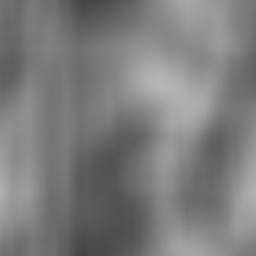

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

# Charger l'image Lena
degraded_image = cv2.imread('/content/noisy.jpg')

# Afficher les images (facultatif)
cv2_imshow(degraded_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

Restauration par Filtrage Spatial
Nous appliquons ici des filtres de lissage (moyenneurs) pour atténuer le bruit. Nous allons tester différentes tailles de fenêtres (sbox) pour observer l'impact sur le compromis entre réduction du bruit et conservation des détails.

Plutôt que de choisir un filtre au hasard, nous implémentons une fonction d'optimisation. Elle itère sur plusieurs tailles de masques pour identifier automatiquement la valeur de sbox qui produit le PSNR maximal. Cette approche permet une restauration objective et automatisée.

Best sbox: 50
Best PSNR: 20.25275774637571


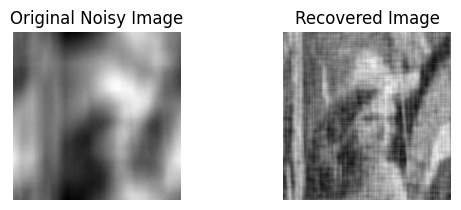

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def apply_filter(input_path, sbox, filter_type, sigma):
    # Load the image
    img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: Unable to load image from {input_path}")
        return None

    m, n = img.shape  # Image size
    img = img.astype(float) / 255.0

    # Convolution
    box = np.zeros((m, n))
    if filter_type == 'horizontal':
        box[0, :sbox] = 1
    elif filter_type == 'vertical':
        box[:sbox, 0] = 1
    elif filter_type == 'square':
        box[:sbox, :sbox] = 1
    box /= np.sum(box)

    # Fourier Transform of the convolution kernel
    Hh = np.fft.fft2(box, (m, n))

    # Add noise
    sigma = np.sqrt(sigma)
    noisy = img + sigma * np.random.randn(*img.shape)
    noisy = np.clip(noisy, 0, 1)
    Gg = np.fft.fft2(noisy)

    # Inverse filtering
    Ffinv = Gg / ((np.abs(Hh) < 1e-1) * 1e-1 + Hh)
    finv = np.abs(np.fft.ifft2(Ffinv))
    finv *= 255.0 / finv.max()

    # Wiener deconvolution
    H2 = np.abs(Hh)**2
    Ffwin = H2 * Gg / (((H2 + sigma) * Hh < 1e-14) * 1e-14 + ((H2 + sigma) * Hh))
    fwin = np.abs(np.fft.ifft2(Ffwin))
    fwin *= 255.0 / fwin.max()

    # Geometric mean filtering
    Ffgeo = (Ffinv ** 1e-7) * (Ffwin ** (1 - 1e-7))
    fgeo = np.abs(np.fft.ifft2(Ffgeo))
    fgeo *= 255.0 / fgeo.max()

    return fgeo.astype(np.uint8)

def calculate_psnr(im1, im2):
    error = im2.astype(float) - im1.astype(float)
    mse = np.mean(error**2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

def find_best_filter(filter_type):
    lena_img = cv2.imread("lena.jpg", cv2.IMREAD_GRAYSCALE)
    best_psnr = 0
    best_sbox = 0
    for sbox in range(1, 257):
        recovered_img = apply_filter("noisy.jpg", sbox, filter_type, 1.5e-7)
        if recovered_img is None:
            continue
        current_psnr = calculate_psnr(lena_img, recovered_img)
        if current_psnr > best_psnr:
            best_sbox = sbox
            best_psnr = current_psnr
    return best_sbox, best_psnr

filter_type = 'square'
best_sbox, best_psnr = find_best_filter(filter_type)
print("Best sbox:", best_sbox)
print("Best PSNR:", best_psnr)
recovered_img = apply_filter("noisy.jpg", best_sbox, filter_type, 1.5e-7)

# Display the original noisy image
noisy_img = cv2.imread("noisy.jpg", cv2.IMREAD_GRAYSCALE)
plt.subplot(2, 2, 1)
plt.imshow(noisy_img, cmap='gray')
plt.title('Original Noisy Image')
plt.axis('off')

# Display the recovered image
if recovered_img is not None:
    plt.subplot(2, 2, 2)
    plt.imshow(recovered_img, cmap='gray')
    plt.title('Recovered Image')
    plt.axis('off')
else:
    print("Error: Unable to recover image")

plt.show()



On remarque qu'à partir d'une image extrêmement floue, au point où il est presque impossible de déchiffrer visuellement son contenu, la fonction find_best_filter a réussi à extraire les meilleurs paramètres possibles.

Avec un Best sbox de 50 et un Best PSNR de 20.25, on obtient une image restaurée bien plus claire. Même si l'image n'est pas parfaite, on distingue désormais nettement la silhouette de Lena, son chapeau, ainsi que les éléments du second plan (background).

C'est le résultat optimal que la fonction pouvait atteindre pour ce type de dégradation. Cela démontre l'efficacité du filtrage de Wiener et de la moyenne géométrique pour stabiliser la restauration et empêcher que le bruit ne prenne le dessus sur les structures réelles de l'image.